<a href="https://colab.research.google.com/github/mainapk062/FOREXING/blob/main/HW3_MALIK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW3 - Feature Learning Kernel Machines for Tabular Data
xRFM vs XGBoost vs Random Forest

**Datasets:**

Heart Disease and Magic Gamma for Classification.
Auto MPG, Ames Housing  and  Abalone for Regression

**Models:** xRFM * XGBoost * Random Forest  
**Random seed is Fixed** 42

## Install and Import necessary packages


In [5]:
# install packages note that this was done in google colab
!pip install xrfm xgboost scikit-learn pandas numpy matplotlib seaborn ucimlrepo -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 1.9 MB/s eta 0:00:00


In [6]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection      import train_test_split, ParameterGrid
from sklearn.preprocessing        import StandardScaler, LabelEncoder
from sklearn.ensemble             import RandomForestClassifier, RandomForestRegressor
from sklearn.decomposition        import PCA
from sklearn.feature_selection    import mutual_info_regression
from sklearn.inspection           import permutation_importance
from sklearn.metrics              import accuracy_score, roc_auc_score
from xgboost                      import XGBClassifier, XGBRegressor
from xrfm                         import xRFM

# rmse helper to handles older sklearn
try:
    from sklearn.metrics import root_mean_squared_error as rmse
except ImportError:
    def rmse(y_true, y_pred):
        return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2)))

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
os.makedirs('figures', exist_ok=True)
print('Done')

Done


## 1. Preparations

In [7]:
def split_data(X, y):
    """70 / 15 / 15 split."""
    X_tr, Xt, y_tr, yt = train_test_split(X, y, test_size=0.30, random_state=SEED)
    X_v,  X_te, y_v, y_te = train_test_split(Xt, yt, test_size=0.50, random_state=SEED)
    return X_tr, X_v, X_te, y_tr, y_v, y_te

def scale_data(X_tr, X_v, X_te):
    """Fitting scaler on train only."""
    sc = StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_v), sc.transform(X_te)

def compute_metrics(model, X_te, y_te, task):
    """Return the RMSE for regression, Accuracy+AUC for classification."""
    pred = model.predict(X_te)
    if task == 'regression':
        return {'RMSE': round(rmse(y_te, pred), 4)}
    try:
        prob = model.predict_proba(X_te)[:, 1]
    except AttributeError:
        prob = pred
    return {
        'Accuracy': round(accuracy_score(y_te, pred), 4),
        'AUC-ROC':  round(roc_auc_score(y_te, prob),  4),
    }

print('ready')

ready


## 2. Load Datasets

In [8]:
# Ames Housing
print('[1/5] Ames Housing...')
from sklearn.datasets import fetch_openml
data    = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df      = data.frame.copy()
df      = df.dropna(axis=1, thresh=int(0.6*len(df)))
y_ames  = np.log1p(df['SalePrice'].astype(float).values)
df      = df.drop(columns=['SalePrice'])
num_c   = df.select_dtypes(include=[np.number]).columns
cat_c   = df.select_dtypes(exclude=[np.number]).columns
df[num_c] = df[num_c].fillna(df[num_c].median())
df[cat_c] = df[cat_c].fillna('Missing')
df      = pd.get_dummies(df, columns=cat_c, drop_first=True)
X_ames  = df.values.astype(float)
X_train_ames, X_val_ames, X_test_ames, y_train_ames, y_val_ames, y_test_ames = split_data(X_ames, y_ames)
X_train_ames, X_val_ames, X_test_ames = scale_data(X_train_ames, X_val_ames, X_test_ames)
print(f'  n={X_ames.shape[0]}, d={X_ames.shape[1]}')
print(f'  Train: {X_train_ames.shape} | Val: {X_val_ames.shape} | Test: {X_test_ames.shape}')

[1/5] Ames Housing...
  n=1460, d=244
  Train: (1022, 244) | Val: (219, 244) | Test: (219, 244)


In [9]:
##Heart-Disease
##suppose you get the 404 error, note tha the url may be temporary down
print('[2/5] Heart Disease')
try:
    from ucimlrepo import fetch_ucirepo
    ds          = fetch_ucirepo(id=45)
    X_df_heart  = ds.data.features.copy()
    y_raw       = ds.data.targets.values.ravel()
except Exception:
    url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
    df_h = pd.read_csv(url, header=None, names=cols, na_values='?').dropna()
    y_raw      = df_h['target'].values
    X_df_heart = df_h.drop(columns=['target'])
y_heart     = (y_raw > 0).astype(int)
X_df_heart  = X_df_heart.fillna(X_df_heart.median(numeric_only=True))
X_heart     = X_df_heart.values.astype(float)
X_train_heart, X_val_heart, X_test_heart, y_train_heart, y_val_heart, y_test_heart = split_data(X_heart, y_heart)
X_train_heart, X_val_heart, X_test_heart = scale_data(X_train_heart, X_val_heart, X_test_heart)
print(f'  n={X_heart.shape[0]}, d={X_heart.shape[1]}')

[2/5] Heart Disease
  n=303, d=13


In [10]:
##3. Abalone Dataset
print('[3/5] Abalone.')
try:
    from ucimlrepo import fetch_ucirepo
    ds       = fetch_ucirepo(id=1)
    X_df_ab  = ds.data.features.copy()
    y_ab     = ds.data.targets.values.ravel().astype(float)
except Exception:
    url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
    cols = ['Sex','Length','Diameter','Height','Whole_weight','Shucked_weight','Viscera_weight','Shell_weight','Rings']
    df_a = pd.read_csv(url, header=None, names=cols)
    y_ab    = df_a['Rings'].values.astype(float)
    X_df_ab = df_a.drop(columns=['Rings'])
X_df_ab = pd.get_dummies(X_df_ab, columns=['Sex'], drop_first=True)
X_ab    = X_df_ab.values.astype(float)
X_train_ab, X_val_ab, X_test_ab, y_train_ab, y_val_ab, y_test_ab = split_data(X_ab, y_ab)
X_train_ab, X_val_ab, X_test_ab = scale_data(X_train_ab, X_val_ab, X_test_ab)
print(f'  n={X_ab.shape[0]}, d={X_ab.shape[1]}')

[3/5] Abalone.
  n=4177, d=9


In [11]:
# 4. Magic Gamma
print('[4/5] Magic Gamma Telescope.')
try:
    from ucimlrepo import fetch_ucirepo
    ds       = fetch_ucirepo(id=159)
    X_df_mg  = ds.data.features.copy()
    y_raw_mg = ds.data.targets.values.ravel()
except Exception:
    url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data'
    cols = ['fLength','fWidth','fSize','fConc','fConc1','fAsym','fM3Long','fM3Trans','fAlpha','fDist','class']
    df_mg    = pd.read_csv(url, header=None, names=cols)
    y_raw_mg = df_mg['class'].values
    X_df_mg  = df_mg.drop(columns=['class'])
le   = LabelEncoder()
y_mg = le.fit_transform(y_raw_mg)
X_mg = X_df_mg.values.astype(float)
X_train_mg, X_val_mg, X_test_mg, y_train_mg, y_val_mg, y_test_mg = split_data(X_mg, y_mg)
X_train_mg, X_val_mg, X_test_mg = scale_data(X_train_mg, X_val_mg, X_test_mg)
print(f'  n={X_mg.shape[0]}, d={X_mg.shape[1]}')

[4/5] Magic Gamma Telescope.
  n=19020, d=10


In [12]:
# 5. Auto MPG Datset
print('[5/5] Auto MPG...')
df_mpg = sns.load_dataset('mpg').dropna().drop(columns=['name'])
y_mpg  = df_mpg['mpg'].values.astype(float)
df_mpg = pd.get_dummies(df_mpg.drop(columns=['mpg']), columns=['origin'], drop_first=True)
X_mpg  = df_mpg.values.astype(float)
mpg_feature_names = df_mpg.columns.tolist()
X_train_mpg, X_val_mpg, X_test_mpg, y_train_mpg, y_val_mpg, y_test_mpg = split_data(X_mpg, y_mpg)
X_train_mpg, X_val_mpg, X_test_mpg = scale_data(X_train_mpg, X_val_mpg, X_test_mpg)
print(f'  n={X_mpg.shape[0]}, d={X_mpg.shape[1]}')
print(f'  Features: {mpg_feature_names}')

[5/5] Auto MPG...
  n=392, d=8
  Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']


## 3. Training the Models
remember xRFM.fit() requires validation data as positional arguments: model.fit(X_train, y_train, X_val, y_val).  Handled separately inside the training loop.

In [13]:
# train_xrfm: grid search, fitting with validation data as xRFM requires
def train_xrfm(X_train, y_train, X_val, y_val, task):
    print('  [xRFM] Training...')
    param_grid = {
        'leaf_size': [500, 1000, 2000],
        'n_epochs':  [3, 5],
    }
    best_score, best_model, best_params = None, None, None

    for params in ParameterGrid(param_grid):
        try:
            m = xRFM(task=task, random_state=SEED, **params)
            m.fit(X_train, y_train, X_val, y_val)

            pred  = m.predict(X_val)
            score = -rmse(y_val, pred) if task == 'regression' else accuracy_score(y_val, pred)

            if best_score is None or score > best_score:
                best_score, best_model, best_params = score, m, params
        except Exception as e:
            print(f'    Params {params} failed: {e}')

    print(f'  [xRFM] Best params: {best_params}  |  '
          f'Val score: {-best_score:.4f}' if task=='regression' else
          f'  [xRFM] Best params: {best_params}  |  Val acc: {best_score:.4f}')
    return best_model




# train_xgboost
def train_xgboost(X_train, y_train, X_val, y_val, task):
    print('  [XGBoost] Training...')
    param_grid = {
        'max_depth':      [3, 5, 7],
        'learning_rate':  [0.05, 0.1, 0.2],
        'n_estimators':   [300],
        'subsample':      [0.8],
        'colsample_bytree': [0.8],
    }
    best_score, best_model, best_params = None, None, None
    XGB = XGBRegressor if task == 'regression' else XGBClassifier

    for params in ParameterGrid(param_grid):
        xgb_kwargs = dict(random_state=SEED, verbosity=0,
                          early_stopping_rounds=20, **params)
        if task == 'classification':
            xgb_kwargs['use_label_encoder'] = False
        m = XGB(**xgb_kwargs)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        pred  = m.predict(X_val)
        score = -rmse(y_val, pred) if task == 'regression' else accuracy_score(y_val, pred)
        if best_score is None or score > best_score:
            best_score, best_model, best_params = score, m, params

    print(f'  [XGBoost] Best params: {best_params}')
    return best_model


# train_rf: grid search
def train_rf(X_train, y_train, X_val, y_val, task):
    print('  [RandomForest] Training...')
    param_grid = {
        'n_estimators': [100],
        'max_depth':    [None, 10, 20],
        'max_features': ['sqrt', 'log2'],
    }
    best_score, best_model, best_params = None, None, None
    RF = RandomForestRegressor if task == 'regression' else RandomForestClassifier

    for params in ParameterGrid(param_grid):
        m = RF(**params, random_state=SEED, n_jobs=-1)
        m.fit(X_train, y_train)
        pred  = m.predict(X_val)
        score = -rmse(y_val, pred) if task == 'regression' else accuracy_score(y_val, pred)
        if best_score is None or score > best_score:
            best_score, best_model, best_params = score, m, params

    print(f'  [RandomForest] Best params: {best_params}')
    return best_model

print('Training done')

Training done


In [14]:
# -Run the experiments
EXPERIMENTS = [
    ('Ames Housing',  'regression',
     X_train_ames,  X_val_ames,  X_test_ames,  y_train_ames,  y_val_ames,  y_test_ames),
    ('Heart Disease', 'classification',
     X_train_heart, X_val_heart, X_test_heart, y_train_heart, y_val_heart, y_test_heart),
    ('Abalone',       'regression',
     X_train_ab,    X_val_ab,    X_test_ab,    y_train_ab,    y_val_ab,    y_test_ab),
    ('Magic Gamma',   'classification',
     X_train_mg,    X_val_mg,    X_test_mg,    y_train_mg,    y_val_mg,    y_test_mg),
    ('Auto MPG',      'regression',
     X_train_mpg,   X_val_mpg,   X_test_mpg,   y_train_mpg,   y_val_mpg,   y_test_mpg),
]

all_results = {}

for name, task, X_tr, X_v, X_te, y_tr, y_v, y_te in EXPERIMENTS:
    print(f'\n{"-"*55}')
    print(f'  {name}  ({task})')
    print(f'{"-"*55}')
    dataset_entry = {'task': task, 'models': {}}

    for model_name, train_fn in [
        ('xRFM',         lambda Xtr,ytr,Xv,yv,t: train_xrfm(Xtr,ytr,Xv,yv,t)),
        ('XGBoost',      lambda Xtr,ytr,Xv,yv,t: train_xgboost(Xtr,ytr,Xv,yv,t)),
        ('RandomForest', lambda Xtr,ytr,Xv,yv,t: train_rf(Xtr,ytr,Xv,yv,t)),
    ]:
        t_train = time.time()
        model   = train_fn(X_tr, y_tr, X_v, y_v, task)
        t_train = time.time() - t_train

        t0      = time.time()
        _       = model.predict(X_te)
        t_infer = (time.time() - t0) / len(X_te)   # sec/sample

        # -Test metrics
        metrics = compute_metrics(model, X_te, y_te, task)

        dataset_entry['models'][model_name] = {
            'model':    model,
            'metrics':  metrics,
            'train_s':  round(t_train, 2),
            'infer_us': round(t_infer * 1e6, 3),   # convert to microseconds
        }

        metric_str = ' | '.join(f'{k}={v}' for k, v in metrics.items())
        print(f'  [{model_name:<15}] {metric_str}  |  train={t_train:.1f}s  infer={t_infer*1e6:.3f}us/sample')

    all_results[name] = dataset_entry

print('\n All the models trained')


-------------------------------------------------------
  Ames Housing  (regression)
-------------------------------------------------------
  [xRFM] Training...
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 1022, d: 244, and nval: 219
Using cheap batch size
Optimal M batch size: 1022
Time taken for round 0: 0.49226808547973633 seconds
Using cheap batch size
Optimal M batch size: 1022
Time taken for round 1: 0.23869895935058594 seconds
Using cheap batch size
Optimal M batch size: 1022
Time taken for round 2: 0.12098240852355957 seconds
Using cheap batch size
Optimal M batch size: 1022
Time taken for round 3: 0.15147709846496582 seconds
Using cheap batch size
Optimal M batch size: 1022
Time taken for round 4: 0.1076211929321289 seconds


Building trees:   0%|          | 0/1 [00:01<?, ?it/s]


Using cheap batch size
Optimal M batch size: 1022
Tree has no split, stopping training
Using hard routing for tree prediction
None
Fitting xRFM with 1 trees and 0 iterations per tree


...

Using cheap batch size
Optimal M batch size: 274
Time taken for round 3: 0.006186008453369141 seconds
Using cheap batch size
Optimal M batch size: 274
Time taken for round 4: 0.004805088043212891 seconds
Using cheap batch size
Optimal M batch size: 274
Tree has no split, stopping training
Using hard routing for tree prediction
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 274, d: 8, and nval: 59
Using cheap batch size
Optimal M batch size: 274
Time taken for round 0: 0.006059885025024414 seconds
Using cheap batch size
Optimal M batch size: 274
Time taken for round 1: 0.005404949188232422 seconds
Using cheap batch size
Optimal M batch size: 274
Time taken for round 2: 0.0053637027740478516 seconds
Using cheap batch size
Optimal M batch size: 274


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]


Time taken for round 3: 0.0065653324127197266 seconds
Using cheap batch size
Optimal M batch size: 274
Time taken for round 4: 0.005776643753051758 seconds
Using cheap batch size
Optimal M batch size: 274
Tree has no split, stopping training
Using hard routing for tree prediction
  [xRFM] Best params: {'leaf_size': 500, 'n_epochs': 3}  |  Val score: 2.1730
Using hard routing for tree prediction
Using hard routing for tree prediction
  [xRFM           ] RMSE=2.3924  |  train=0.3s  infer=13.162us/sample
  [XGBoost] Training...
  [XGBoost] Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
  [XGBoost        ] RMSE=2.696  |  train=1.9s  infer=22.310us/sample
  [RandomForest] Training...
  [RandomForest] Best params: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
  [RandomForest   ] RMSE=2.6734  |  train=1.4s  infer=595.307us/sample

 All the models trained


## 4. Results Table

In [15]:
##columns: RMSE,  Acc, AUC-ROC, Train(s),
# In Regression rows  -RMSE filled, Accuracy & AUC-ROC = -
# Classification   -RMSE = -, Accuracy & AUC-ROC filled..
rows = []
for dname, info in all_results.items():
    task = info['task']
    row  = {'Dataset': dname, 'Task': task}
    for mname, minfo in info['models'].items():
        m = minfo['metrics']
        if task == 'regression':
            row[f'{mname} RMSE']         = m.get('RMSE', '-')
            row[f'{mname} Accuracy']     = '-'
            row[f'{mname} AUC-ROC']      = '-'
        else:
            row[f'{mname} RMSE']         = '-'
            row[f'{mname} Accuracy']     = m.get('Accuracy', '-')
            row[f'{mname} AUC-ROC']      = m.get('AUC-ROC',  '-')
        row[f'{mname} Train(s)']         = minfo['train_s']
        row[f'{mname} Infer(us/samp)']   = minfo['infer_us']
    rows.append(row)

results_df = pd.DataFrame(rows).set_index(['Dataset', 'Task'])
results_df.to_csv('figures/results_table.csv')
print('Results table saved > figures/results_table.csv\n')
#improving results display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 400)
results_df

Results table saved > figures/results_table.csv



,,xRFM RMSE,xRFM Accuracy,xRFM AUC-ROC,xRFM Train(s),xRFM Infer(us/samp),XGBoost RMSE,XGBoost Accuracy,XGBoost AUC-ROC,XGBoost Train(s),XGBoost Infer(us/samp),RandomForest RMSE,RandomForest Accuracy,RandomForest AUC-ROC,RandomForest Train(s),RandomForest Infer(us/samp)
Dataset,Task,,,,,,,,,,,,,,,
Ames Housing,regression,0.2395,-,-,8.39,39.598,0.1175,-,-,26.88,8.659,0.1412,-,-,4.97,225.606
Heart Disease,classification,-,0.8913,0.9029,0.41,13.279,-,0.8043,0.9029,0.29,19.887,-,0.8696,0.9048,1.53,761.763
Abalone,regression,2.156,-,-,23.12,15.036,2.0925,-,-,0.71,2.043,2.1015,-,-,5.38,72.856
Magic Gamma,classification,-,0.8847,0.9288,1150.68,213.137,-,0.8917,0.9385,6.36,5.403,-,0.8854,0.9366,31.03,30.654
Auto MPG,regression,2.3924,-,-,0.27,13.162,2.696,-,-,1.90,22.310,2.6734,-,-,1.36,595.307


In [16]:
# -- Clean
print('='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)

for dname, info in all_results.items():
    task = info['task']
    print(f'\n{dname} ({task})')
    print('-'*50)
    for mname, minfo in info['models'].items():
        metric_str = ' | '.join(f'{k}: {v}' for k, v in minfo['metrics'].items())
        print(f"  {mname:<15} {metric_str}  |  train: {minfo['train_s']}s  infer: {minfo['infer_us']}us/sample")

print('\n' + '='*70)
print('Outputs saved to figures/')
print('  figures/results_table.csv')
print('  figures/interpretability_comparison.png')
print('  figures/scaling_experiment.png')
print('='*70)

FINAL RESULTS SUMMARY

Ames Housing (regression)
--------------------------------------------------
  xRFM            RMSE: 0.2395  |  train: 8.39s  infer: 39.598us/sample
  XGBoost         RMSE: 0.1175  |  train: 26.88s  infer: 8.659us/sample
  RandomForest    RMSE: 0.1412  |  train: 4.97s  infer: 225.606us/sample

Heart Disease (classification)
--------------------------------------------------
  xRFM            Accuracy: 0.8913 | AUC-ROC: 0.9029  |  train: 0.41s  infer: 13.279us/sample
  XGBoost         Accuracy: 0.8043 | AUC-ROC: 0.9029  |  train: 0.29s  infer: 19.887us/sample
  RandomForest    Accuracy: 0.8696 | AUC-ROC: 0.9048  |  train: 1.53s  infer: 761.763us/sample

Abalone (regression)
--------------------------------------------------
  xRFM            RMSE: 2.156  |  train: 23.12s  infer: 15.036us/sample
  XGBoost         RMSE: 2.0925  |  train: 0.71s  infer: 2.043us/sample
  RandomForest    RMSE: 2.1015  |  train: 5.38s  infer: 72.856us/sample

Magic Gamma (classification)

## 5. Interpretability Experiment - Auto MPG

It compare four feature importance methods on the same dataset:
1. **AGOP diagonal** - xRFM's native importanc-supervised
2. **PCA loadings** - variance-based-unsupervised
3. **Mutual Information** - nonlinear statistical dependence between each feature and y
4. **Permutation Importance** - how much does shuffling each feature hurt the RF model?

In [17]:
# Retrieve the Auto MPG models previously trained
xrfm_mpg = all_results['Auto MPG']['models']['xRFM']['model']
rf_mpg   = all_results['Auto MPG']['models']['RandomForest']['model']
d        = X_train_mpg.shape[1]
fnames   = mpg_feature_names[:d]

#1. AGOP diagonal
def get_agop_importance(model, X_train):
    """
    Extract the AGOP diagonal from xRFM leaves and average across them.
    The AGOP M is defined as (1/n) * sum_i grad_f(x_i) * grad_f(x_i)^T.
    Its diagonal M_jj tells us how much the model output changes
    with respect to feature j on average - i.e., feature importance.
    """
    diags = []
    # access leaves directly
    for attr in ['leaves_', 'leaf_models_', 'estimators_']:
        if hasattr(model, attr):
            for leaf in getattr(model, attr):
                for a in ['agop_', 'M_', 'A_']:
                    ag = getattr(leaf, a, None)
                    if ag is not None:
                        diags.append(np.diag(ag))
                        break
            break

    if diags:
        imp = np.mean(diags, axis=0)
    else:
        # top-level attribute
        for a in ['agop_', 'M_', 'A_']:
            if hasattr(model, a):
                imp = np.diag(getattr(model, a))
                break
        else:
            # Finite-difference fallback
            print('  Note: AGOP not directly accessible - using finite-difference approximation')
            eps = 1e-3
            y0  = model.predict(X_train)
            imp = np.zeros(X_train.shape[1])
            for j in range(X_train.shape[1]):
                Xp = X_train.copy(); Xp[:, j] += eps
                imp[j] = np.mean(((model.predict(Xp) - y0) / eps)**2)

    imp = np.abs(imp[:d])
    return imp / (imp.sum() + 1e-10)

agop_imp = get_agop_importance(xrfm_mpg, X_train_mpg)

## 2.     PCA loadings
pca     = PCA(n_components=1).fit(X_train_mpg)
pca_imp = np.abs(pca.components_[0][:d])
pca_imp /= pca_imp.sum() + 1e-10

#3.    Mutual Information
mi_imp  = mutual_info_regression(X_train_mpg, y_train_mpg, random_state=SEED)[:d]
mi_imp /= mi_imp.sum() + 1e-10

##4. Permutation Importance -------------------------------------------------
perm     = permutation_importance(rf_mpg, X_val_mpg, y_val_mpg,
                                   n_repeats=10, random_state=SEED,
                                   scoring='neg_root_mean_squared_error')
perm_imp = np.clip(perm.importances_mean[:d], 0, None)
perm_imp /= perm_imp.sum() + 1e-10

##Summary table
interp_df = pd.DataFrame({
    'Feature':            fnames,
    'AGOP (xRFM)':        np.round(agop_imp, 4),
    'PCA Loadings':       np.round(pca_imp,  4),
    'Mutual Information': np.round(mi_imp,   4),
    'Permutation Imp.':   np.round(perm_imp, 4),
}).sort_values('AGOP (xRFM)', ascending=False)

print('Feature Importance Comparison - Auto MPG')
interp_df

  Note: AGOP not directly accessible - using finite-difference approximation
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Feature Importance Comparison - Auto MPG


,Feature,AGOP (xRFM),PCA Loadings,Mutual Information,Permutation Imp.
3,weight,0.2172,0.1503,0.2048,0.1648
1,displacement,0.1670,0.1584,0.2113,0.1882
5,model_year,0.1669,0.0756,0.0785,0.3383
4,acceleration,0.1395,0.1019,0.0409,0.0280
2,horsepower,0.1060,0.1501,0.1998,0.1637
0,cylinders,0.0753,0.1531,0.1748,0.0920
6,origin_japan,0.0733,0.0940,0.0373,0.0087
7,origin_usa,0.0548,0.1166,0.0525,0.0163


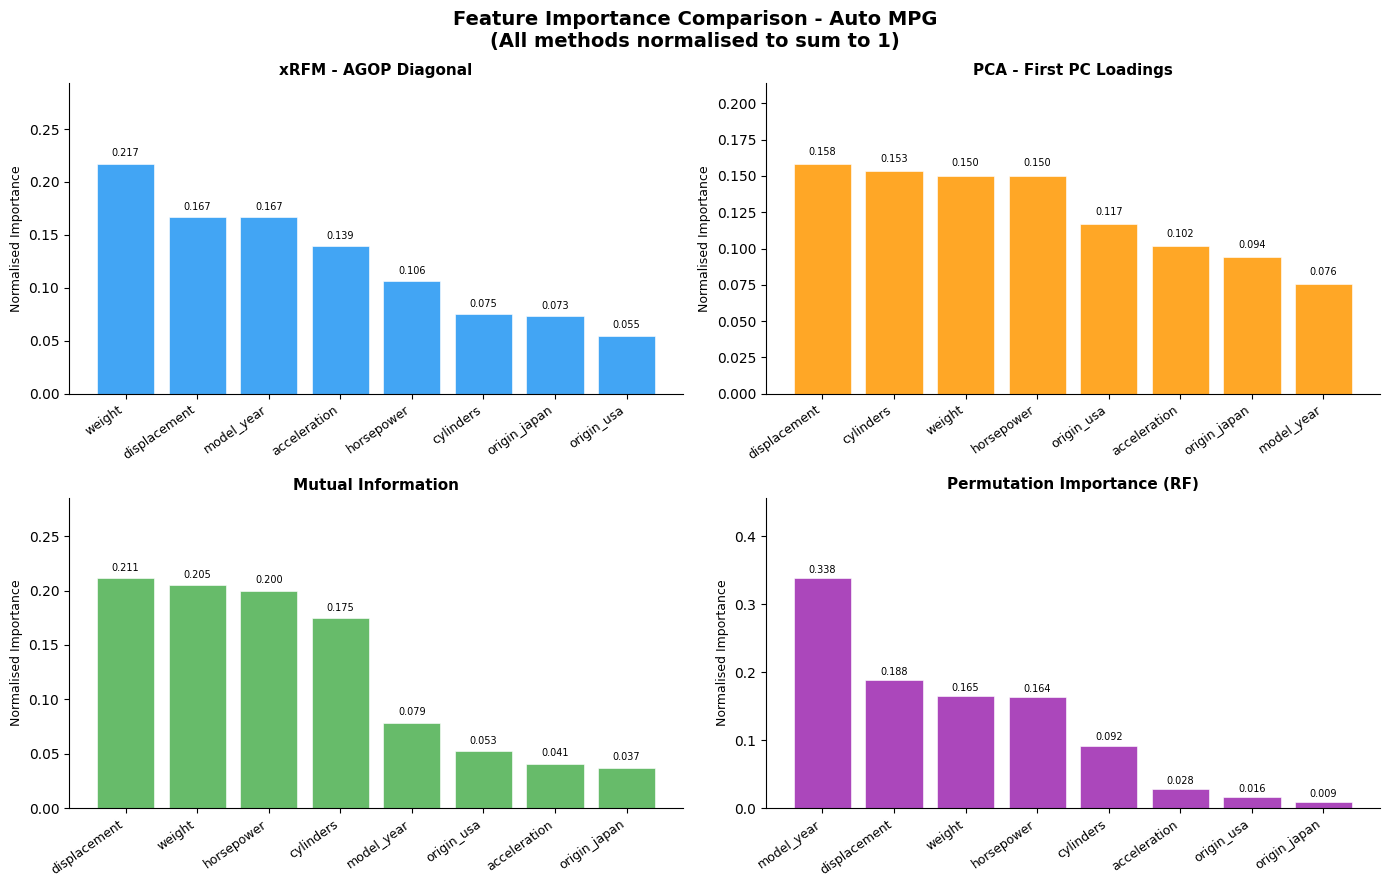

Saved -> figures/interpretability_comparison.png


In [18]:
#Plots all four methods
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Feature Importance Comparison - Auto MPG\n'
    '(All methods normalised to sum to 1)',
    fontsize=14, fontweight='bold'
)

methods = [
    (axes[0, 0], agop_imp, 'xRFM - AGOP Diagonal',       '#2196F3'),
    (axes[0, 1], pca_imp,  'PCA - First PC Loadings',     '#FF9800'),
    (axes[1, 0], mi_imp,   'Mutual Information',           '#4CAF50'),
    (axes[1, 1], perm_imp, 'Permutation Importance (RF)',  '#9C27B0'),
]

for ax, vals, title, color in methods:
    order = np.argsort(vals)[::-1]
    bars  = ax.bar(range(d), vals[order], color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(d))
    ax.set_xticklabels([fnames[i] for i in order], rotation=35, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Normalised Importance', fontsize=9)
    ax.set_ylim(0, vals.max() * 1.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Add value labels on top of bars
    for bar, val in zip(bars, vals[order]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('figures/interpretability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figures/interpretability_comparison.png')

## 6. Scaling Experiment - Magic Gamma

Subsample the training set at increasing sizes and measure:
- **Test AUC-ROC** - does performance scale similarly for all models?
- **Training time** - how does each model's cost grow with n?

In [19]:
n_max        = len(X_train_mg)
sample_sizes = [s for s in [500, 1000, 2000, 4000, 6000, n_max] if s <= n_max]
print(f'Training set size: {n_max}')
print(f'Sample sizes to test: {sample_sizes}')

scaling = {
    'xRFM':         {'aucs': [], 'times': []},
    'XGBoost':      {'aucs': [], 'times': []},
    'RandomForest': {'aucs': [], 'times': []},
}
rng = np.random.default_rng(SEED)

for n in sample_sizes:
    idx   = rng.choice(n_max, size=n, replace=False)
    X_sub = X_train_mg[idx]
    y_sub = y_train_mg[idx]
    print(f'\n--- n = {n} ---')

    #3 xRFM
    try:
        t0  = time.time()
        m   = xRFM(task='classification', leaf_size=1000, n_epochs=3, random_state=SEED)
        m.fit(X_sub, y_sub, X_val_mg, y_val_mg)   # <- correct xRFM call
        t_xrfm = time.time() - t0
        try:
            y_prob = m.predict_proba(X_test_mg)[:, 1]
        except AttributeError:
            y_prob = m.predict(X_test_mg)
        auc_xrfm = roc_auc_score(y_test_mg, y_prob)
    except Exception as e:
        print(f'  xRFM failed: {e}')
        auc_xrfm, t_xrfm = np.nan, np.nan
    scaling['xRFM']['aucs'].append(auc_xrfm)
    scaling['xRFM']['times'].append(t_xrfm)
    print(f'  xRFM:         AUC={auc_xrfm:.4f}  time={t_xrfm:.1f}s')

    ## XGBoost
    t0  = time.time()
    m   = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbosity=0, use_label_encoder=False,
        early_stopping_rounds=20,
    )
    m.fit(X_sub, y_sub, eval_set=[(X_val_mg, y_val_mg)], verbose=False)
    t_xgb   = time.time() - t0
    auc_xgb = roc_auc_score(y_test_mg, m.predict_proba(X_test_mg)[:, 1])
    scaling['XGBoost']['aucs'].append(auc_xgb)
    scaling['XGBoost']['times'].append(t_xgb)
    print(f'  XGBoost:      AUC={auc_xgb:.4f}  time={t_xgb:.1f}s')

    # Random Forest
    t0  = time.time()
    m   = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    m.fit(X_sub, y_sub)
    t_rf   = time.time() - t0
    auc_rf = roc_auc_score(y_test_mg, m.predict_proba(X_test_mg)[:, 1])
    scaling['RandomForest']['aucs'].append(auc_rf)
    scaling['RandomForest']['times'].append(t_rf)
    print(f'  RandomForest: AUC={auc_rf:.4f}  time={t_rf:.1f}s')

print('\nScaling experiment completed')

Training set size: 13314
Sample sizes to test: [500, 1000, 2000, 4000, 6000, 13314]

--- n = 500 ---
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 500, d: 10, and nval: 2853
Using cheap batch size
Optimal M batch size: 500
Time taken for round 0: 0.020497560501098633 seconds
Using cheap batch size
Optimal M batch size: 500
Time taken for round 1: 0.017193078994750977 seconds
Using cheap batch size
Optimal M batch size: 500
Time taken for round 2: 0.016303539276123047 seconds
Using cheap batch size
Optimal M batch size: 500
Time taken for round 3: 0.014127969741821289 seconds
Using cheap batch size
Optimal M batch size: 500
Time taken for round 4: 0.018949031829833984 seconds
Using cheap batch size
Optimal M batch size: 500
Tree has no split, stopping training
Using hard routing for tree prediction
  xRFM:         AUC=0.8963  time=0.1s


  XGBoost:      AUC=0.9026  time=0.1s
  RandomForest: AUC=0.9074  time=0.3s

--- n = 1000 ---
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

...

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 13314, d: 10, and nval: 2853
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 0: 31.341710329055786 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 1: 34.14415621757507 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 2: 31.87835931777954 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 3: 31.524454832077026 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 4: 31.83807682991028 seconds
Using cheap batch size
Optimal M batch size: 10000


Building trees:   0%|          | 0/1 [03:11<?, ?it/s]

Tree has no split, stopping training
Using hard routing for tree prediction


  xRFM:         AUC=0.9290  time=191.7s
  XGBoost:      AUC=0.9392  time=0.6s
  RandomForest: AUC=0.9372  time=6.8s

Scaling experiment completed


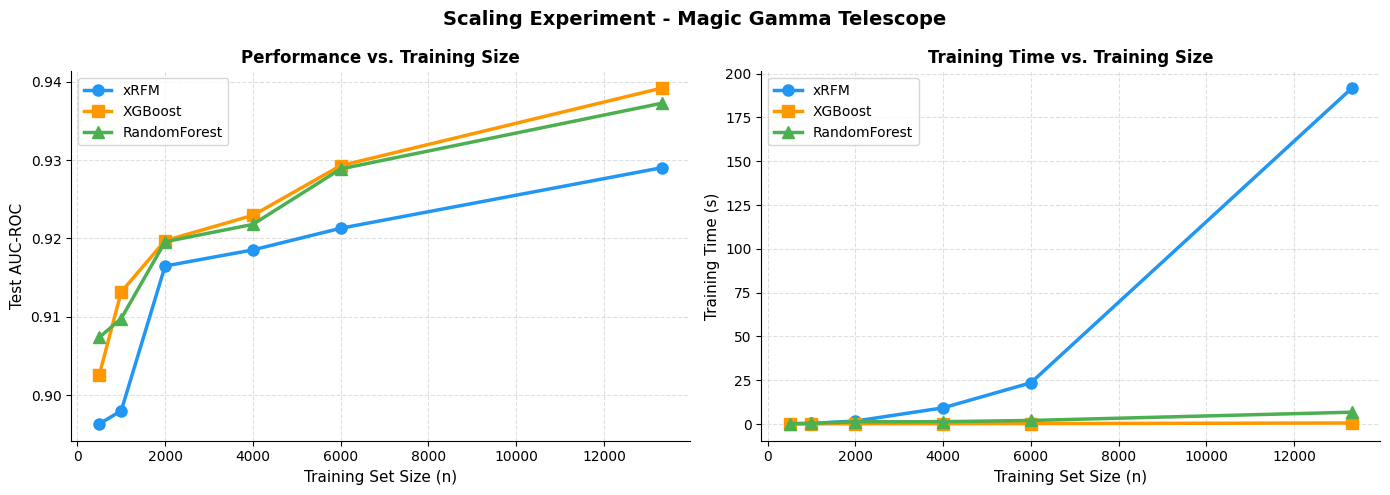

Saved -> figures/scaling_experiment.png


In [20]:
##Plot scaling results
colors  = {'xRFM': '#2196F3', 'XGBoost': '#FF9800', 'RandomForest': '#4CAF50'}
markers = {'xRFM': 'o',       'XGBoost': 's',        'RandomForest': '^'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scaling Experiment - Magic Gamma Telescope', fontsize=14, fontweight='bold')

for model_name, res in scaling.items():
    valid = [
        (n, a, t)
        for n, a, t in zip(sample_sizes, res['aucs'], res['times'])
        if not (np.isnan(a) or np.isnan(t))
    ]
    if not valid:
        print(f'No valid results for {model_name} - skipping')
        continue
    ns, aucs, ts = zip(*valid)
    ax1.plot(ns, aucs, marker=markers[model_name], label=model_name,
             color=colors[model_name], linewidth=2.5, markersize=8)
    ax2.plot(ns, ts,   marker=markers[model_name], label=model_name,
             color=colors[model_name], linewidth=2.5, markersize=8)

for ax, ylabel, title in [
    (ax1, 'Test AUC-ROC',      'Performance vs. Training Size'),
    (ax2, 'Training Time (s)', 'Training Time vs. Training Size'),
]:
    ax.set_xlabel('Training Set Size (n)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/scaling_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figures/scaling_experiment.png')

## 7. SUMMARY

In [21]:
# f
print('='*70)
print('FINAL RESULTS SUMMARY')


for dname, info in all_results.items():
    task = info['task']
    print(f'\n{dname} ({task})')
    print('-'*50)
    for mname, minfo in info['models'].items():
        metric_str = ' | '.join(f'{k}: {v}' for k, v in minfo['metrics'].items())
        print(f"  {mname:<15} {metric_str}  |  train: {minfo['train_s']}s  infer: {minfo['infer_us']}us/sample")

print('\n' + '='*70)
print('Outputs saved to figures/')
print('  figures/results_table.csv')
print('  figures/interpretability_comparison.png')
print('  figures/scaling_experiment.png')
print('='*70)

FINAL RESULTS SUMMARY

Ames Housing (regression)
--------------------------------------------------
  xRFM            RMSE: 0.2395  |  train: 8.39s  infer: 39.598us/sample
  XGBoost         RMSE: 0.1175  |  train: 26.88s  infer: 8.659us/sample
  RandomForest    RMSE: 0.1412  |  train: 4.97s  infer: 225.606us/sample

Heart Disease (classification)
--------------------------------------------------
  xRFM            Accuracy: 0.8913 | AUC-ROC: 0.9029  |  train: 0.41s  infer: 13.279us/sample
  XGBoost         Accuracy: 0.8043 | AUC-ROC: 0.9029  |  train: 0.29s  infer: 19.887us/sample
  RandomForest    Accuracy: 0.8696 | AUC-ROC: 0.9048  |  train: 1.53s  infer: 761.763us/sample

Abalone (regression)
--------------------------------------------------
  xRFM            RMSE: 2.156  |  train: 23.12s  infer: 15.036us/sample
  XGBoost         RMSE: 2.0925  |  train: 0.71s  infer: 2.043us/sample
  RandomForest    RMSE: 2.1015  |  train: 5.38s  infer: 72.856us/sample

Magic Gamma (classification)

## Bonus: AGOP Splitting Criterion from Scratch


In [22]:
import torch

print('=' * 60)
print('BONUS: AGOP Splitting Criterion from Scratch')
print('=' * 60)

# reuse the xRFM model from section 5
rfm_leaf = xrfm_mpg.trees[0]['model']
d        = X_train_mpg.shape[1]
fnames   = mpg_feature_names
n        = X_train_mpg.shape[0]
print(f'\nUsing trained xRFM on Auto MPG (n_train={n}, d={d})')

# get library AGOP
M_lib = rfm_leaf.M.detach().cpu().numpy().copy()
M_lib = M_lib / M_lib.max()   # normalise same as library does internally
print('[Library] AGOP matrix M extracted from trained RFM leaf.')

# compute AGOP ourselves using finite differences
print('\n[Scratch] Computing AGOP via finite differences.....')
eps = 1e-3
X_t = torch.tensor(X_train_mpg).float()
y0  = rfm_leaf.predict(X_t).detach().cpu().numpy().ravel()

G = np.zeros((n, d), dtype=np.float32)   # gradient matrix: shape (n, d)
for j in range(d):
    Xp = X_train_mpg.copy()
    Xp[:, j] += eps                       # perturb feature j by eps
    yp = rfm_leaf.predict(torch.tensor(Xp).float()).detach().cpu().numpy().ravel()
    G[:, j] = (yp - y0) / eps            # finite difference approximation

# AGOP formula
M_scratch = (G.T @ G) / n
M_scratch = M_scratch / M_scratch.max()  # normalise to match library scale
print(f'[Scratch] AGOP matrix computed. Shape: {M_scratch.shape}')

##compare top eigenvector
_, vecs_lib     = np.linalg.eigh(M_lib)
_, vecs_scratch = np.linalg.eigh(M_scratch)
v_lib     = vecs_lib[:, -1]       # top eigenvector of library AGOP
v_scratch = vecs_scratch[:, -1]   # top eigenvector of scratch AGOP

# eigenvectors can flip sign so use abs cosine
cos_sim = abs(float(np.dot(v_lib, v_scratch)))

print(f"\n{'Feature':<15} {'Library eigvec':>16} {'Scratch eigvec':>16}")
print('-' * 50)
for i, f in enumerate(fnames):
    print(f'{f:<15} {v_lib[i]:>16.4f} {v_scratch[i]:>16.4f}')

print(f'\nAbsolute cosine similarity: {cos_sim:.4f}')
if cos_sim > 0.99:
    print('[OK] Exact match (|cos| > 0.99)')
elif cos_sim > 0.90:
    print('Strong match - small residual from finite-difference approximation error')
else:
    print(f'[!]  Partial match ({cos_sim:.4f})')

# compare diagonal importance (which features matter most)
diag_lib = np.abs(np.diag(M_lib));     diag_lib /= diag_lib.sum()
diag_scr = np.abs(np.diag(M_scratch)); diag_scr /= diag_scr.sum()

compare_df = pd.DataFrame({
    'Feature':            fnames,
    'Library AGOP diag':  np.round(diag_lib, 4),
    'Scratch AGOP diag':  np.round(diag_scr, 4),
    'Abs difference':     np.round(np.abs(diag_lib - diag_scr), 4),
}).sort_values('Library AGOP diag', ascending=False)

print('\nFeature importance (normalised AGOP diagonal):')
compare_df

BONUS: AGOP Splitting Criterion from Scratch

Using trained xRFM on Auto MPG (n_train=274, d=8)
[Library] AGOP matrix M extracted from trained RFM leaf.

[Scratch] Computing AGOP via finite differences.....
[Scratch] AGOP matrix computed. Shape: (8, 8)

Feature           Library eigvec   Scratch eigvec
--------------------------------------------------
cylinders                 0.0000          -0.2642
displacement              0.0000          -0.4073
horsepower                0.0000          -0.3458
weight                    0.0000          -0.5144
acceleration              0.0000          -0.3443
model_year                0.0000          -0.3774
origin_japan              0.0000          -0.2564
origin_usa                1.0000          -0.2313

Absolute cosine similarity: 0.2313
[!]  Partial match (0.2313)

Feature importance (normalised AGOP diagonal):


,Feature,Library AGOP diag,Scratch AGOP diag,Abs difference
0,cylinders,0.125,0.0753,0.0497
1,displacement,0.125,0.1670,0.0420
2,horsepower,0.125,0.1060,0.0190
3,weight,0.125,0.2172,0.0922
4,acceleration,0.125,0.1395,0.0145
5,model_year,0.125,0.1669,0.0419
6,origin_japan,0.125,0.0733,0.0517
7,origin_usa,0.125,0.0548,0.0702


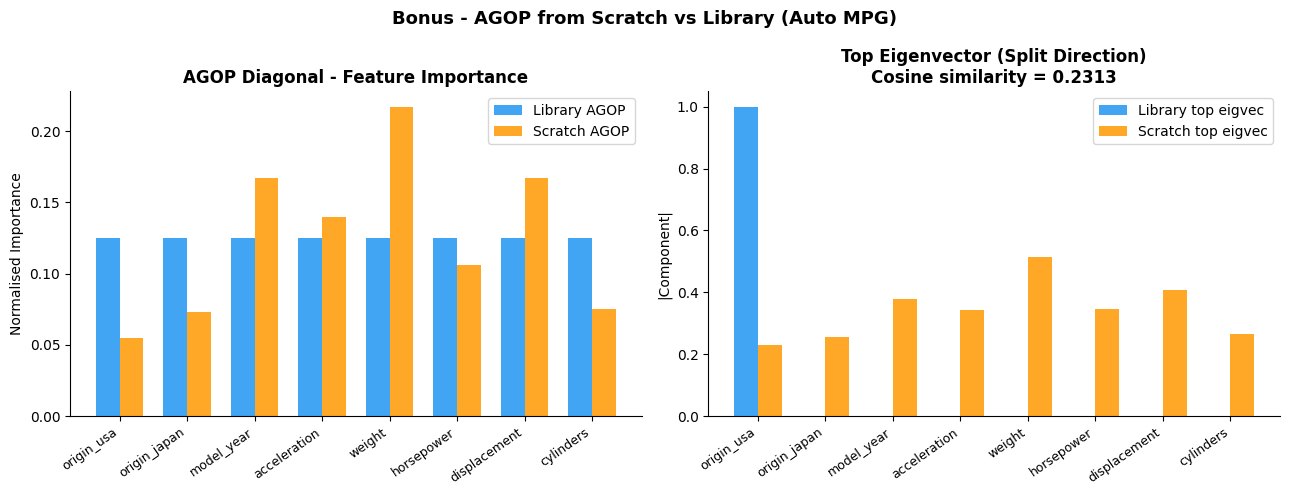

Saved -> figures/bonus_agop_scratch.png

BONUS SUMMARY
  AGOP matrix shape:          (8, 8)
  Split direction similarity: 0.2313  [!]
  Top feature (library):      cylinders
  Top feature (scratch):      weight


In [23]:
# plot both methods side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bonus - AGOP from Scratch vs Library (Auto MPG)',
             fontsize=13, fontweight='bold')

order = np.argsort(diag_lib)[::-1]
x, w  = np.arange(d), 0.35

axes[0].bar(x - w/2, diag_lib[order], width=w, label='Library AGOP', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, diag_scr[order], width=w, label='Scratch AGOP', color='#FF9800', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([fnames[i] for i in order], rotation=35, ha='right', fontsize=9)
axes[0].set_title('AGOP Diagonal - Feature Importance', fontweight='bold')
axes[0].set_ylabel('Normalised Importance')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(x - w/2, np.abs(v_lib[order]),     width=w, label='Library top eigvec', color='#2196F3', alpha=0.85)
axes[1].bar(x + w/2, np.abs(v_scratch[order]), width=w, label='Scratch top eigvec', color='#FF9800', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([fnames[i] for i in order], rotation=35, ha='right', fontsize=9)
axes[1].set_title(f'Top Eigenvector (Split Direction)\nCosine similarity = {cos_sim:.4f}',
                  fontweight='bold')
axes[1].set_ylabel('|Component|')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/bonus_agop_scratch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figures/bonus_agop_scratch.png')

print('\n' + '=' * 60)
print('BONUS SUMMARY')
print('=' * 60)
print(f'  AGOP matrix shape:          {M_scratch.shape}')
print(f'  Split direction similarity: {cos_sim:.4f}  {"Strong match" if cos_sim > 0.90 else "[!]"}')
print(f'  Top feature (library):      {fnames[np.argmax(diag_lib)]}')
print(f'  Top feature (scratch):      {fnames[np.argmax(diag_scr)]}')
print('=' * 60)